In [23]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/auto-mpg02.csv")
df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [24]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [25]:
t1 = dict(zip(df.columns, ['연비', '실린더수', '배기량', '마력','무게','가속능력','출시연도','제조국','모델명']))
df.rename(columns=t1, inplace=True)

In [26]:
df.head()

,연비,실린더수,배기량,마력,무게,가속능력,출시연도,제조국,모델명
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [27]:
df.dtypes

연비      float64
실린더수      int64
배기량     float64
마력       object
무게        int64
가속능력    float64
출시연도      int64
제조국       int64
모델명      object
dtype: object

In [28]:
# 마력이 '?' 인것 95로 채우기
c1 = (df['마력'] == '?')

In [29]:
df.loc[c1,['마력']] = '95'

In [30]:
df.dropna()

,연비,실린더수,배기량,마력,무게,가속능력,출시연도,제조국,모델명
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [31]:
df['마력'].unique

<bound method Series.unique of 0      130
1      165
2      150
3      150
4      140
5      198
6      220
7      215
8      225
9      190
10     170
11     160
12     150
13     225
14      95
15      95
16      97
17      85
18      88
19      46
20      87
21      90
22      95
23     113
24      90
25     215
26     200
27     210
28     193
29      88
30      90
31      95
32      95
33     100
34     105
35     100
36      88
37     100
38     165
39     175
40     153
41     150
42     180
43     170
44     175
45     110
46      72
47     100
48      88
49      86
50      90
51      70
52      76
53      65
54      69
55      60
56      70
57      95
58      80
59      54
60      90
61      86
62     165
63     175
64     150
65     153
66     150
67     208
68     155
69     160
70     190
71      97
72     150
73     130
74     140
75     150
76     112
77      76
78      87
79      69
80      86
81      92
82      97
83      80
84      88
85     175
86     150
87     145
8

In [32]:
df = df.astype({'마력': 'float64'})
df.dtypes


연비      float64
실린더수      int64
배기량     float64
마력      float64
무게        int64
가속능력    float64
출시연도      int64
제조국       int64
모델명      object
dtype: object

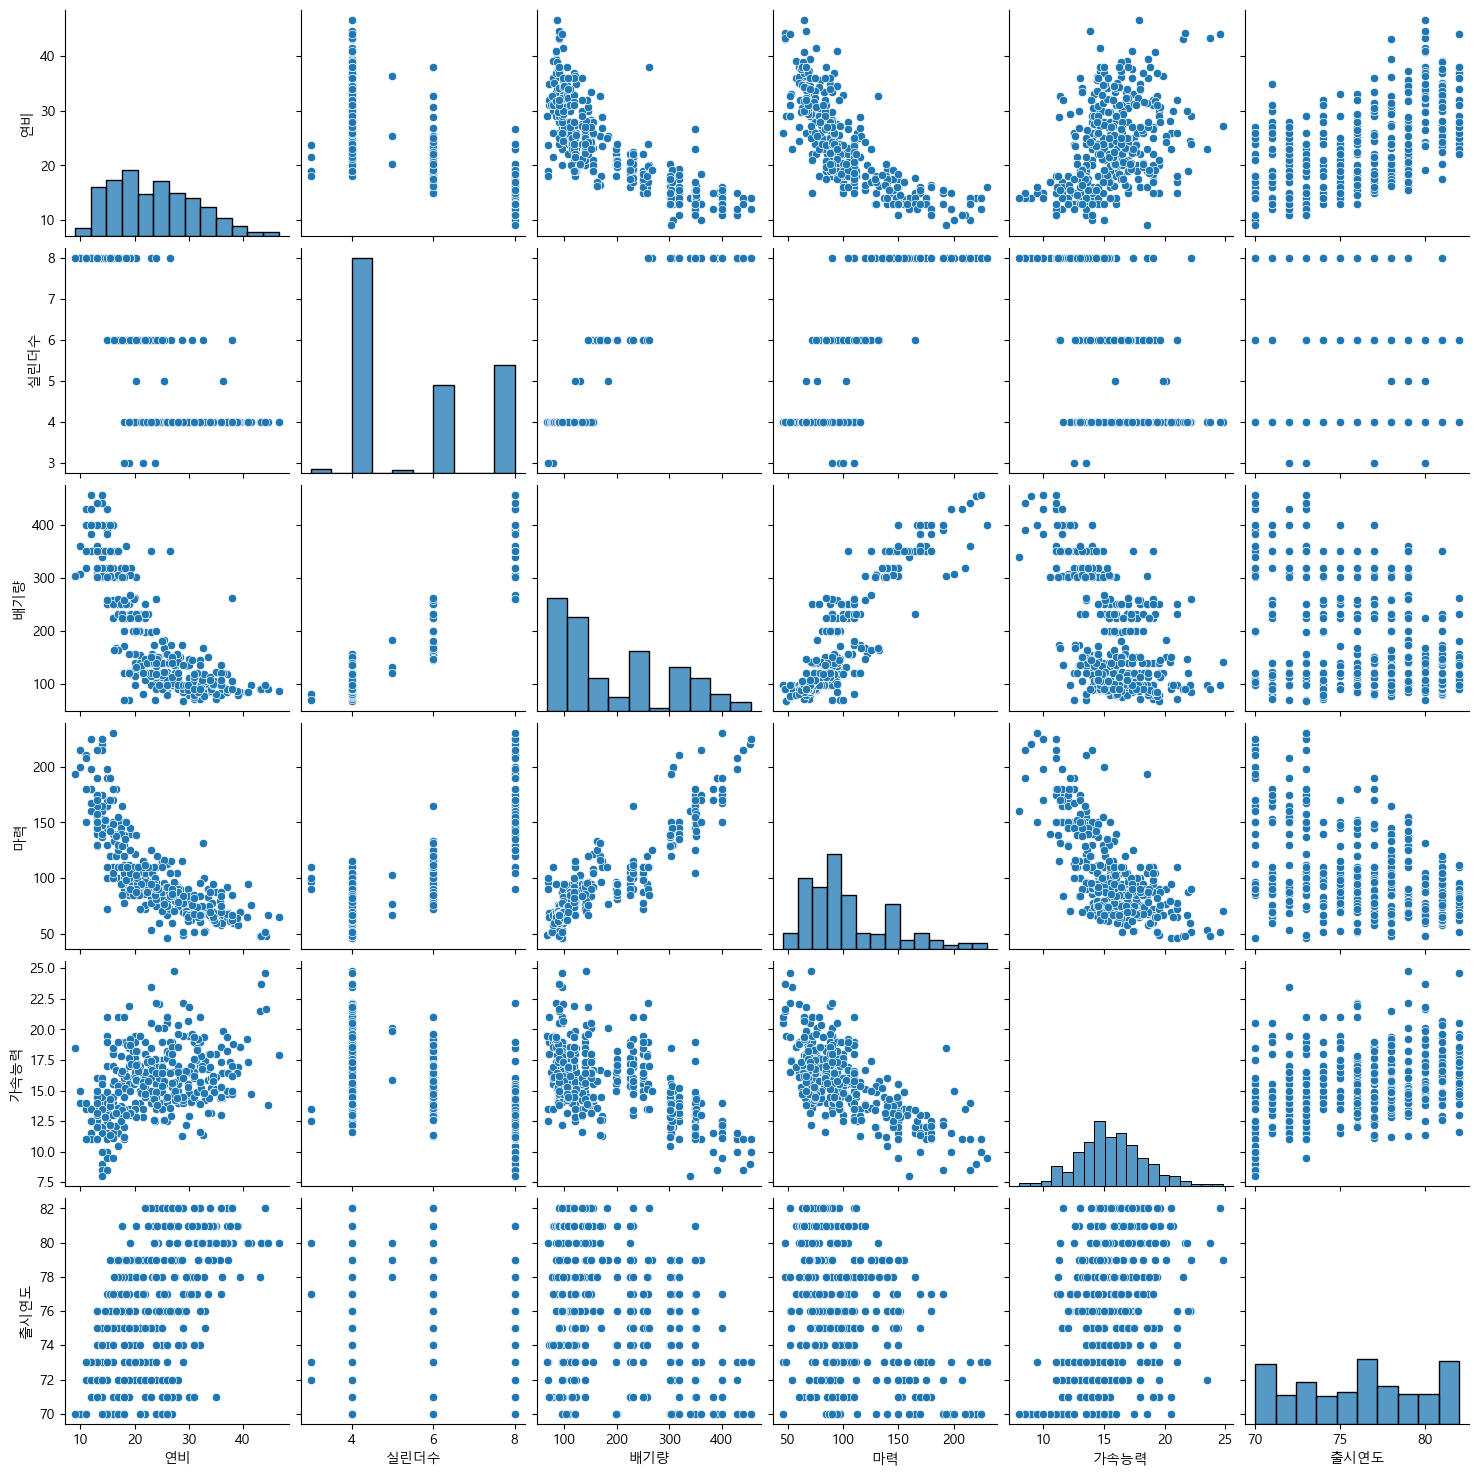

In [51]:
import seaborn as sns
import seaborn_cjk
import matplotlib.pyplot as plt

seaborn_cjk.patch()

sns.pairplot(df[['연비', '실린더수', '배기량', '마력', '가속능력', '출시연도',]])
plt.show()

In [52]:
from sklearn.model_selection import train_test_split

x = df[['배기량', '연비', '가속능력']]
# x = df[['마력']]
y = df['마력']



In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=10)

lr1 = LinearRegression()
lr1.fit(x_train, y_train)
print('pre poly:', lr1.score(x_train, y_train) , lr1.score(x_test, y_test))

poly = PolynomialFeatures(degree=4, include_bias=False)
poly.fit(x_train)
x_train_poly = poly.transform(x_train)
x_test_poly = poly.transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_poly, y_train)
print('after poly:',lr2.score( x_train_poly, y_train), lr2.score(x_test_poly, y_test))

lasso = Lasso()
lasso.fit(x_train_poly, y_train)
print("after lasso:", lasso.score(x_train_poly, y_train), lasso.score(x_test_poly, y_test))

pre poly: 0.8741081466008995 0.8407983173830944
after poly: 0.9351141773434302 0.9037375567961987
after lasso: 0.9179619622323425 0.8594890753768052


c:\Users\kst\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.943e+04, tolerance: 4.714e+01
  model = cd_fast.enet_coordinate_descent(


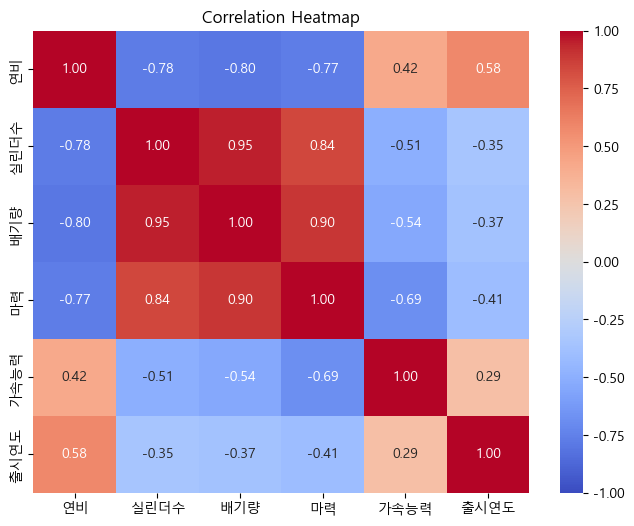

In [94]:
# 2. 상관관계 계산
corr = df[['연비', '실린더수', '배기량', '마력', '가속능력', '출시연도',]].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()